In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

N = 700          # количество шагов
delta = 500      # масштабный коэффициент (Δ)
x0, y0 = 1, 0    # начальные координаты

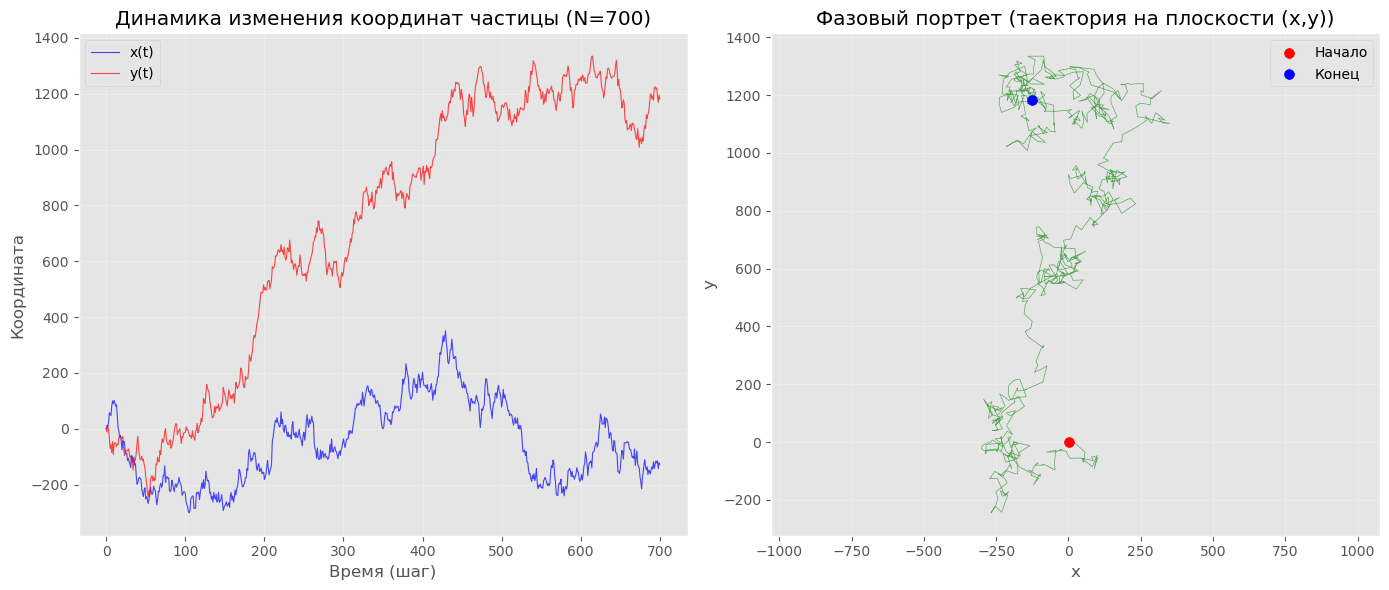

Длина траектории: 701 точек
Диапазон по x: [-301.47, 350.62]
Диапазон по y: [-245.16, 1334.68]


In [2]:
# 1. Моделирование броуновского движения (винеровский процесс)

def brownian_motion(N, x0, y0, scale=1.0):
    """
    Генерирует 2D броуновское движение.
    scale - коэффициент диффузии (Δ)
    """
    # Генерация случайных приращений (нормальное распределение)
    dx = np.random.normal(0, scale, N)
    dy = np.random.normal(0, scale, N)
    
    # Вычисление траектории
    x = np.zeros(N+1)
    y = np.zeros(N+1)
    x[0], y[0] = x0, y0
    
    for i in range(N):
        x[i+1] = x[i] + dx[i]
        y[i+1] = y[i] + dy[i]
    
    return x, y

# Генерация траектории
np.random.seed(42)  # для воспроизводимости
x_traj, y_traj = brownian_motion(N, x0, y0, scale=np.sqrt(delta))

# Визуализация траектории
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График динамики координат во времени
time = np.arange(N+1)
axes[0].plot(time, x_traj, 'b-', alpha=0.7, label='x(t)', linewidth=0.8)
axes[0].plot(time, y_traj, 'r-', alpha=0.7, label='y(t)', linewidth=0.8)
axes[0].set_xlabel('Время (шаг)')
axes[0].set_ylabel('Координата')
axes[0].set_title(f'Динамика изменения координат частицы (N={N})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Фазовый портрет (траектория на плоскости)
axes[1].plot(x_traj, y_traj, 'g-', alpha=0.6, linewidth=0.5)
axes[1].scatter(x_traj[0], y_traj[0], c='red', s=50, label='Начало', zorder=5)
axes[1].scatter(x_traj[-1], y_traj[-1], c='blue', s=50, label='Конец', zorder=5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(f'Фазовый портрет (таектория на плоскости (x,y))')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print(f"Длина траектории: {len(x_traj)} точек")
print(f"Диапазон по x: [{np.min(x_traj):.2f}, {np.max(x_traj):.2f}]")
print(f"Диапазон по y: [{np.min(y_traj):.2f}, {np.max(y_traj):.2f}]")

Наклон зависимости ln(L) от ln(ε): slope = -0.7189
Фрактальная размерность (Ричардсон): D = 1 - slope = 1.7189


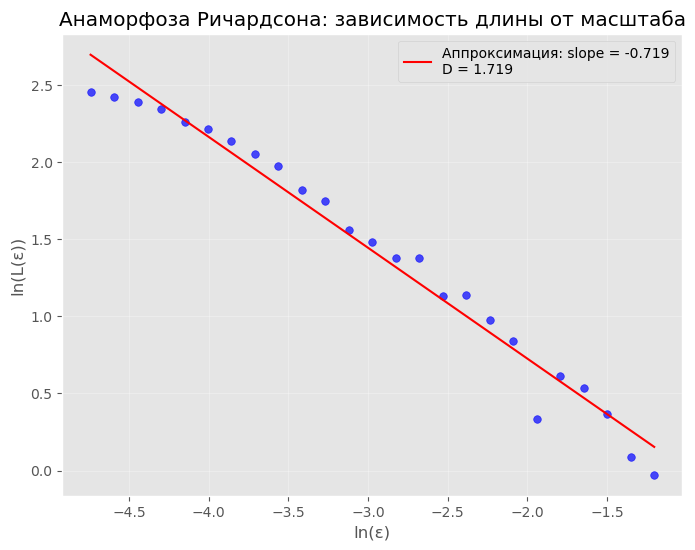

In [ ]:
def richardson_dimension(x, y, eps_min=None, eps_max=None, n_points=25):
    """
    Оценка фрактальной размерности методом Ричардсона.
    Исправленная версия: D = 1 - slope, где slope - наклон зависимости ln(L) от ln(ε)
    """
    # Масштабируем координаты
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)
    scale = max(x_max - x_min, y_max - y_min)
    x_norm = (x - x_min) / scale
    y_norm = (y - y_min) / scale
    
    # Определяем диапазон масштабов
    if eps_min is None:
        # Минимальный масштаб - среднее расстояние между соседними точками
        points = np.column_stack((x_norm, y_norm))
        diffs = np.diff(points, axis=0)
        distances = np.linalg.norm(diffs, axis=1)
        eps_min = np.mean(distances) * 0.5
    
    if eps_max is None:
        eps_max = 0.3  # доля от размера области
    
    epsilons = np.logspace(np.log10(eps_min), np.log10(eps_max), n_points)
    lengths = []
    
    points = np.column_stack((x_norm, y_norm))
    
    for eps in epsilons:
        # Метод "шагающего циркуля"
        length = 0.0
        current_point = points[0]
        i = 0
        
        while i < len(points) - 1:
            # Ищем точку на расстоянии >= eps
            j = i + 1
            found = False
            while j < len(points):
                dist = np.linalg.norm(points[j] - points[i])
                if dist >= eps:
                    length += dist
                    i = j
                    found = True
                    break
                j += 1
            
            if not found:
                # Добавляем расстояние до последней точки
                if i < len(points) - 1:
                    length += np.linalg.norm(points[-1] - points[i])
                break
        
        lengths.append(length)
    
    # Логарифмическая анаморфоза
    log_eps = np.log(epsilons)  # ln(ε)
    log_len = np.log(lengths)   # ln(L(ε))
    
    # Линейная регрессия
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_eps, log_len)
    
    dimension = 1 - slope
    
    return dimension, intercept, slope, log_eps, log_len, epsilons, lengths

# Оценка размерности методом Ричардсона
dim_rich, intercept_rich, slope_rich, log_eps_rich, log_len_rich, eps_rich, len_rich = richardson_dimension(
    x_traj, y_traj, n_points=25)

print(f"Наклон зависимости ln(L) от ln(ε): slope = {slope_rich:.4f}")
print(f"Фрактальная размерность (Ричардсон): D = 1 - slope = {dim_rich:.4f}")

# Визуализация анаморфозы Ричардсона
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log_eps_rich, log_len_rich, c='blue', alpha=0.7, s=30)
ax.plot(log_eps_rich, slope_rich * log_eps_rich + intercept_rich, 'r-', 
        label=f'Аппроксимация: slope = {slope_rich:.3f}\nD = {dim_rich:.3f}')
ax.set_xlabel('ln(ε)')
ax.set_ylabel('ln(L(ε))')
ax.set_title('Анаморфоза Ричардсона: зависимость длины от масштаба')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Оценка фрактальной размерности сеточным методом Фёдера...
Фрактальная размерность (сеточный метод): D = 1.3874


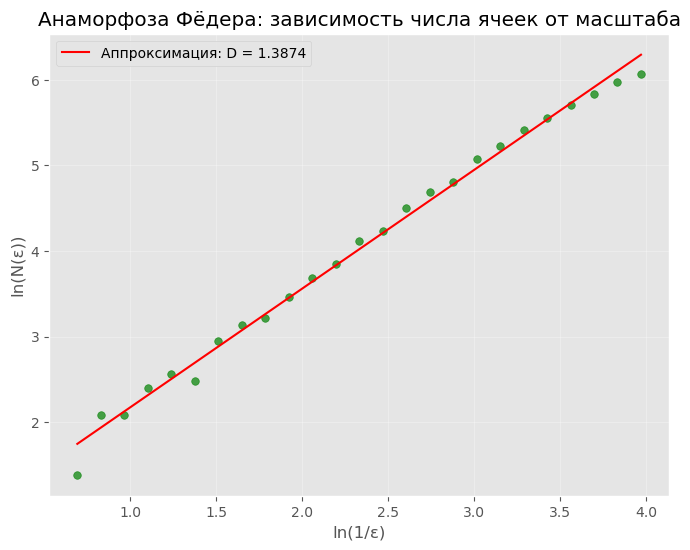

In [14]:
def box_counting_dimension(x, y, eps_min=None, eps_max=None, n_scales=25):
    """
    Оценка фрактальной размерности сеточным методом (box-counting).
    D = lim_{ε→0} log(N(ε)) / log(1/ε)
    """
    # Нормализация на единичный квадрат
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)
    
    # Небольшой отступ для границ
    padding = 0.001 * max(x_max - x_min, y_max - y_min)
    x_min -= padding
    x_max += padding
    y_min -= padding
    y_max += padding
    
    # Нормализация
    x_norm = (x - x_min) / (x_max - x_min)
    y_norm = (y - y_min) / (y_max - y_min)
    points = np.column_stack((x_norm, y_norm))
    
    # Определение диапазона размеров ячеек
    if eps_max is None:
        eps_max = 0.5  # максимальный размер ячейки
    if eps_min is None:
        eps_min = 1.0 / (len(points) ** 0.5) * 0.5
    
    epsilons = np.logspace(np.log10(eps_min), np.log10(eps_max), n_scales)
    box_counts = []
    
    for eps in epsilons:
        # Подсчет ячеек
        ix = np.floor(points[:, 0] / eps).astype(int)
        iy = np.floor(points[:, 1] / eps).astype(int)
        
        # Уникальные ячейки
        cells = set(zip(ix, iy))
        box_counts.append(len(cells))
    
    # Анаморфоза: log(N(ε)) vs log(1/ε)
    log_inv_eps = np.log(1.0 / epsilons)
    log_counts = np.log(box_counts)
    
    # Линейная регрессия
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_inv_eps, log_counts)
    dimension = slope
    
    return dimension, intercept, slope, log_inv_eps, log_counts, epsilons, box_counts

# Оценка размерности сеточным методом
print("Оценка фрактальной размерности сеточным методом Фёдера...")
dim_box, intercept_box, slope_box, log_inv_eps_box, log_counts_box, eps_box, counts_box = box_counting_dimension(
    x_traj, y_traj, n_scales=25
)

print(f"Фрактальная размерность (сеточный метод): D = {dim_box:.4f}")

# Визуализация анаморфозы Фёдера
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log_inv_eps_box, log_counts_box, c='green', alpha=0.7, s=30)
ax.plot(log_inv_eps_box, slope_box * log_inv_eps_box + intercept_box, 'r-',
        label=f'Аппроксимация: D = {dim_box:.4f}')
ax.set_xlabel('ln(1/ε)')
ax.set_ylabel('ln(N(ε))')
ax.set_title('Анаморфоза Фёдера: зависимость числа ячеек от масштаба')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

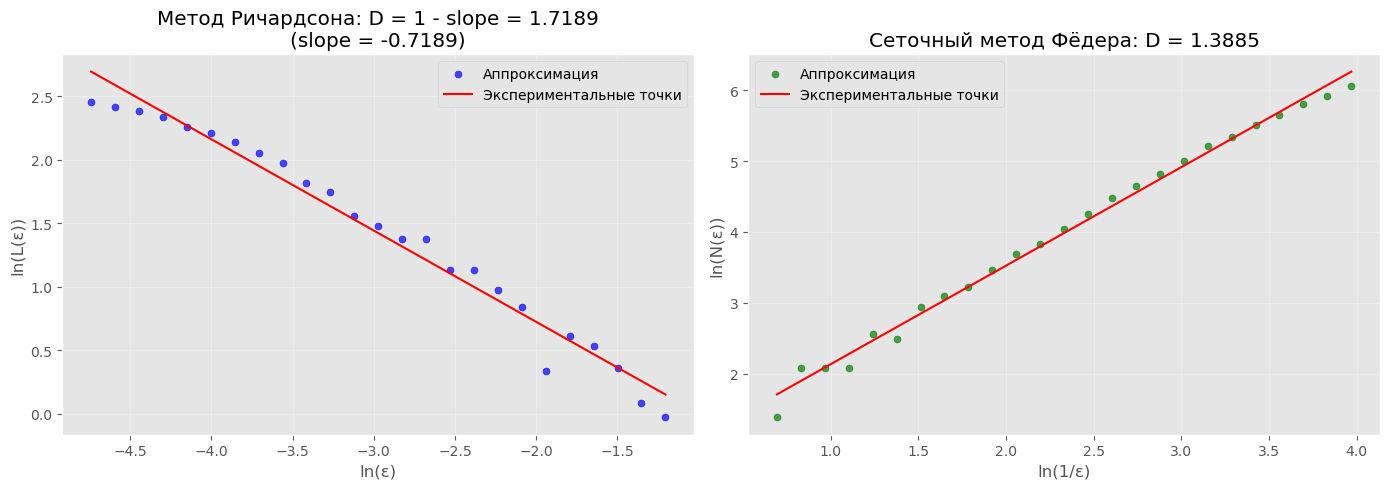

In [13]:
# Итоговая визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Анаморфоза Ричардсона (исправленная версия с ln(ε))
axes[0].scatter(log_eps_rich, log_len_rich, c='blue', alpha=0.7, s=25)
axes[0].plot(log_eps_rich, slope_rich * log_eps_rich + intercept_rich, 'r-', linewidth=1.5)
axes[0].set_xlabel('ln(ε)')
axes[0].set_ylabel('ln(L(ε))')
axes[0].set_title(f'Метод Ричардсона: D = 1 - slope = {dim_rich:.4f}\n(slope = {slope_rich:.4f})')
axes[0].grid(True, alpha=0.3)
axes[0].legend(['Аппроксимация', 'Экспериментальные точки'], loc='best')

# Анаморфоза Фёдера
axes[1].scatter(log_inv_eps_box, log_counts_box, c='green', alpha=0.7, s=25)
axes[1].plot(log_inv_eps_box, slope_box * log_inv_eps_box + intercept_box, 'r-', linewidth=1.5)
axes[1].set_xlabel('ln(1/ε)')
axes[1].set_ylabel('ln(N(ε))')
axes[1].set_title(f'Сеточный метод Фёдера: D = {dim_box:.4f}')
axes[1].grid(True, alpha=0.3)
axes[1].legend(['Аппроксимация', 'Экспериментальные точки'], loc='best')

plt.tight_layout()
plt.show()